<a href="https://colab.research.google.com/github/raswinpeeris14-hub/Movie-Analysis/blob/main/movieboxoffice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("tmdb5000movies.csv")
print(df.head(3))
print("================================")
print("Size:\n",df.size)
print("Shape:\n",df.shape)
print("Describe:\n",df.describe())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "name": "spy"}, {"id": 818, "name...                en   

                             original_title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   

        

In [5]:
#find missing values
miss_values=df.isna().sum()
print(miss_values)

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64


In [6]:
drop_values=df.dropna()
print(drop_values.head())
print("Size After:",drop_values.size)
print("Information:",drop_values.info())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [19]:
df.duplicated()
df_clean=drop_values.copy()
df_clean.to_csv("cleandata.csv",index=False)
print(df_clean.head())
print("Size After:",df_clean.size)
print("Information:",df_clean.info())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [37]:
df_subset = df_clean[['title', 'budget', 'revenue']].copy()
df_subset = df_subset[(df_subset['budget'] > 0) & (df_subset['revenue'] > 0)]
df_clean['profit'] = df['revenue'] - df['budget']
df_clean['status'] = df_clean['profit'].apply(lambda x: 'Profitable' if x > 0 else 'Loss')
print(df_clean['profit'])
print(df_clean['status'])
print(df_clean.head())

0       2550965087
1        661000000
2        635674609
3        834939099
4         24139100
           ...    
4773       3124130
4781        -22000
4791           -13
4796        417760
4801             0
Name: profit, Length: 1493, dtype: int64
0       Profitable
1       Profitable
2       Profitable
3       Profitable
4       Profitable
           ...    
4773    Profitable
4781          Loss
4791          Loss
4796    Profitable
4801          Loss
Name: status, Length: 1493, dtype: object
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatar

In [39]:
budget_cutoff = df_subset['budget'].quantile(0.75)
high_budget_movies = df_subset[df_subset['budget'] >= budget_cutoff]

high_budget_movies = high_budget_movies.copy()
high_budget_movies['profit'] = high_budget_movies['revenue'] - high_budget_movies['budget']

profitable_high_budget = high_budget_movies[high_budget_movies['profit'] > 0]
profitable_high_budget = profitable_high_budget.sort_values(by='profit', ascending=False)

print(profitable_high_budget)
success_rate = (len(profitable_high_budget) / len(high_budget_movies)) * 100


                         title     budget     revenue      profit
0                       Avatar  237000000  2787965087  2550965087
25                     Titanic  200000000  1845034188  1645034188
28              Jurassic World  150000000  1513528810  1363528810
44                   Furious 7  190000000  1506249360  1316249360
16                The Avengers  220000000  1519557910  1299557910
..                         ...        ...         ...         ...
260               Ender's Game  110000000   125537191    15537191
61           Jupiter Ascending  176000003   183987723     7987720
547               Sucker Punch   82000000    89792502     7792502
48       Jack the Giant Slayer  195000000   197687603     2687603
293  Where the Wild Things Are  100000000   100086793       86793

[290 rows x 4 columns]


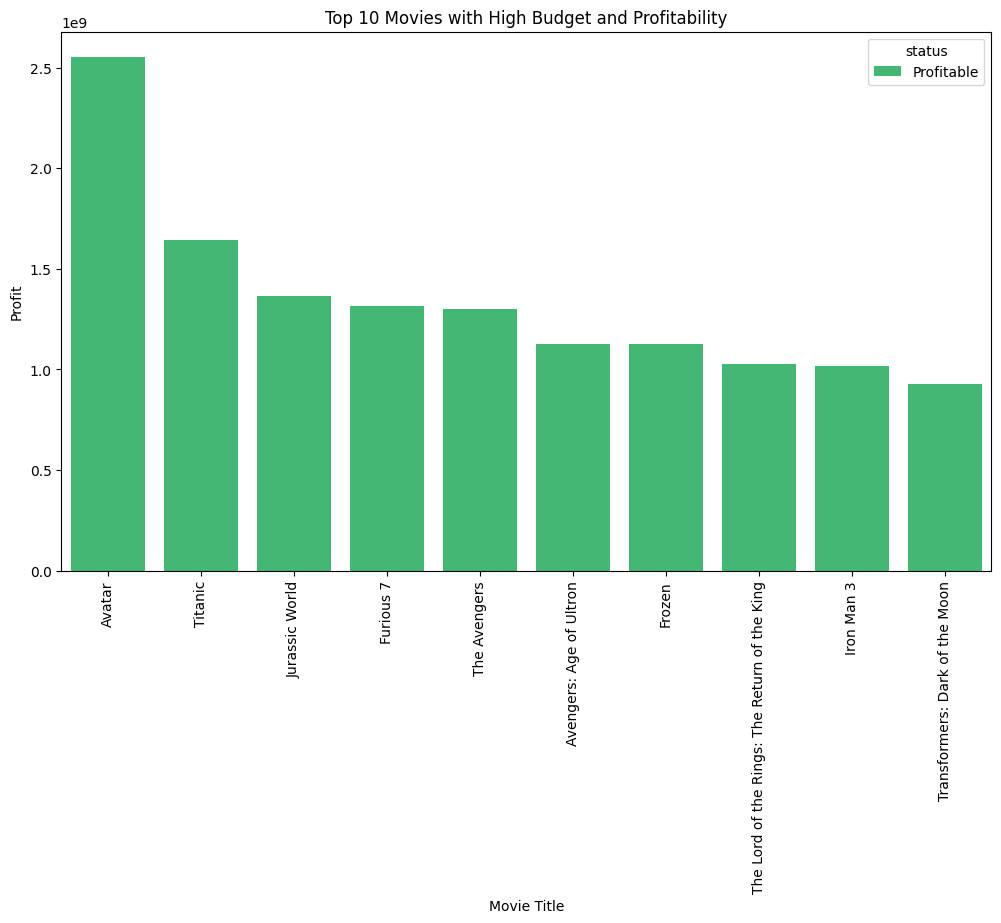

In [42]:
profitable_high_budget['status'] = 'Profitable'

plt.figure(figsize=(12, 7))
sns.barplot(
    x='title',
    y='profit',
    data=profitable_high_budget.head(10),
    hue='status',
    palette={'Profitable': '#2ecc71', 'Loss': '#e74c3c'}
)
plt.xticks(rotation=90)
plt.xlabel('Movie Title')
plt.ylabel('Profit')
plt.title('Top 10 Movies with High Budget and Profitability')
plt.show()
